# MARS Behavior Classification Demo

This is the tutorial from the readme of MARS_Developer in Jupyter notebook form. If nothing else is stated just execute the cells.

## 1. 📁 Create a new MARS Training Project

Your MARS project directory will contain all the files created during the process of training MARS detector and pose models on your data.

If you've previously trained MARS pose models for your data, you can keep using the same directory here. Otherwise, run the cell below:

In [ ]:
# Only run this cell if folder 'verify_paper_results' does not exist in the project dir


# from create_new_project import *

# location = './'
# name = 'verify_paper_results'

# create_new_project(location, name, download_MARS_checkpoints=False, download_demo_data=False)

(Skip this step if you didn't execute the code above) Within your project folder is a file called `project_config.yaml`. This file contains many important features: keypoint and animal names, instructions for your annotation job, and names/data assignments for detection and pose models. Open this file in a text editor and fill in the fields as instructed in the comments. 

## 2. 💪 Training behavior classifiers

For now, we assume that you have already trained MARS pose estimators on your dataset, and extracted some pose data from a set of videos. Now, we're going to learn to detect behaviors in these videos!

MARS is a *supervised* classification system, meaning that it requires labeled training examples of the behaviors you would like to detect.

You can use our Matlab-based interface [Bento](https://github.com/neuroethology/bentoMAT) to create frame-by-frame manual annotations of behavioral videos- for more information see [this page](https://github.com/neuroethology/bentoMAT/wiki/Annotating-Your-Data) of the Bento wiki. (A Python version of Bento will be available soon.)

### 2.1 Assemble your videos and annotations

To train MARS behavior classifiers, you will need to add the following files to `project_path\behavior\behavior_data`:
- Download the official MARS dataset from [The Mouse Action Recognition System (MARS): behavior annotation data](https://data.caltech.edu/records/7mh1s-yph35)
    - Files: `train.zip`, `validation.zip`, `test_1.zip`

MARS uses a filename-based system for matching up videos to their corresponding pose estimates and annotations: so long as video, annotation, and pose estimates all begin with the same string, MARS will do its best to match them.

To check that all your files are found and paired up correctly, call `check_annotation_data`:

In [3]:
from behavior_classification import behavior_setup

PROJECT_PATH = 'verify_paper_results'

behavior_setup.check_behavior_data(PROJECT_PATH)

Processing behavior annotations in project verify_paper_results
  112 total videos found.
  all videos successfully matched with annotation and pose files!
List of behavior annotations found:
  attack
  investigation
  mount


If everything seems to be in order, use `prep_behavior_data_according_to_paper` to split your dataset into training, validation, and test sets (Just execute the cell).

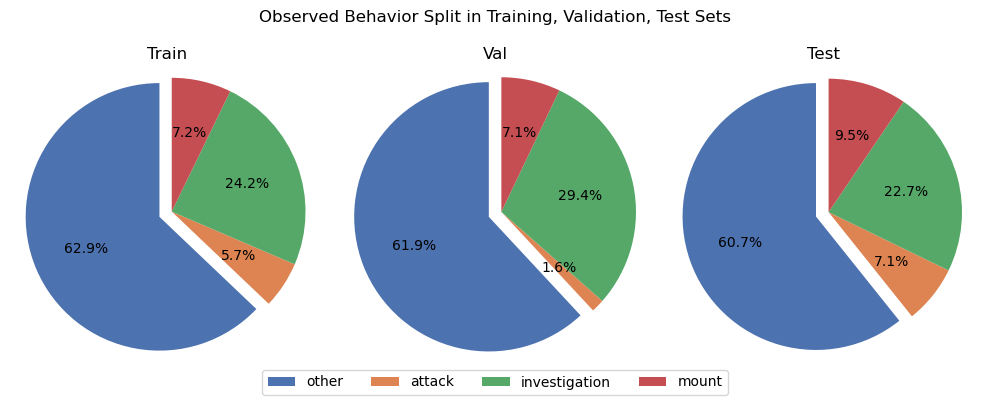

list of all observed annotations:
['attack', 'investigation', 'mount', 'other']


In [ ]:
from behavior_classification import behavior_setup

PROJECT_PATH = 'verify_paper_results'

behavior_setup.prep_behavior_data_according_to_paper(PROJECT_PATH,
                                                     drop_label='',
                                                     train_dir=[f'{PROJECT_PATH}/behavior/behavior_data/train/'],
                                                     test_dir=[f'{PROJECT_PATH}/behavior/behavior_data/test_1/'],
                                                     val_dir=[f'{PROJECT_PATH}/behavior/behavior_data/validation/'])

Finally, once you're happy with your splits, call `apply_clf_splits` to package data for classifier training. This script packages pose and annotation data into `.json` files, using the formatting convention established for [the CalMS21 dataset](https://data.caltech.edu/records/1991):

```json
{
    "vocabulary": {
        "other": 0,
        "(behavior_1)": 1,
        "(behavior_2)": 2
    }
    "sequences": {
        "my_project": {
            "name_of_video_1": {
                "keypoints": [],
                "bbox": [],
                "scores": [],
                "annotations": [],
                "metadata": {}
            },
            "name_of_video_2": {
                "keypoints": [],
                "bbox": [],
                "scores": [],
                "annotations": [],
                "metadata": {}        
            },
        }
    }
}
```
The `metadata` field will contain your original file paths, for safekeeping. Annotations are converted to a vector of integers, whose mapping to behavior labels is defined by the `vocabulary` dictionary.

In [ ]:
from behavior_classification import behavior_setup

PROJECT_PATH = 'verify_paper_results'

behavior_setup.apply_clf_splits(PROJECT_PATH)

saving train set...


### 2.2 Extract features from pose/video files

MARS extracts a set of custom-designed features from animals' poses, and uses these features to detect behaviors of interest.

Feature extraction is currently only supported for poses using the original MARS keypoint definitions (nose, ears, neck, hips, and tail, from two mice.) An update supporting more general feature extraction is in progress.

In [ ]:
from behavior_classification import MARS_feature_extractor

project_path = 'verify_paper_results'

MARS_feature_extractor.extract_features(project_path, sideload_features=False)

### 2.3 Define annotation equivalences
If your training data is compiled from many old experiments, you may discover that annotators have used different names to refer to the same behavior. Or, you may want to combine multiple more fine-grained labels to create a broader behavior classifier.

MARS allows you to combine behaviors by creating `equivalences`, implemented as a python dictionary. For example, the following `equivalences` dictionary would look for any of the labels listed on the right, and use these as positive examples when training a classifier to detect the behavior `sniff_face`:

```
equivalences = {'sniff_face': ['sniffface', 'sniff-face', 'sniff_face', 'head-investigation','facesniffing']}
```

You can define `equivalences` for your project using the `set_equivalences` function. If you don't call this function, MARS will only look for annotations that match your target behavior exactly.

In [ ]:
from behavior_classification import behavior_setup

equivalences = {'sniff_face':     ['sniffface', 'snifface', 'sniff-face', 'sniff_face',
                                   'head-investigation','facesniffing'],
            'sniff_genital':      ['sniffurogenital','sniffgenitals','sniff_genitals',
                                   'sniff-genital','sniff_genital','anogen-investigation'],
            'sniff_body':         ['sniff_body','sniffbody','bodysniffing','body-investigation',
                                   'socialgrooming','sniff-body','closeinvestigate',
                                   'closeinvestigation','investigation'],
            'investigation':      ['sniffface', 'snifface', 'sniff-face', 'sniff_face',
                                   'head-investigation','facesniffing','sniffurogenital',
                                   'sniffgenitals','sniff_genitals','sniff-genital',
                                   'sniff_genital','anogen-investigation','sniff_body',
                                   'sniffbody', 'bodysniffing', 'body-investigation',
                                   'socialgrooming','sniff-body', 'closeinvestigate',
                                   'closeinvestigation', 'investigation','investigate',
                                   'first_inv','aggressive_investigation','attack_attempt',
                                   'mount_attempt','dom_mount_attempt'],
            'mount':              ['mount','aggressivemount','intromission','dom_mount','ejaculate'],
            'attack':             ['attack','attempted_attack','chase']}


PROJECT_PATH = 'verify_paper_results'

behavior_setup.set_equivalences(PROJECT_PATH, equivalences)

### 2.4 Train your behavior classifier!

Finally, you can use the following command to train a new MARS classifier for a specified behavior of interest. MARS will check the `equivalences` you defined above; if it finds the specified behavior among the dictionary keys, it will include all corresponding entries associated with that key when defining positive examples of that behavior.

The CAPSLOCK variables (e.g. `SAMPLING_STRATS`,`SAMPLING_PCTS`) define the parameters for the experiments used in the thesis. Also where outputs go, and how many reruns are made for each strat. The rest is just wrapper code to handle printing output to a file, rename folders, create error logs etc.

For each rerun x sampling strategy x sampling percentag combination, the cell below does:

1. Updates the YAML configuration to reflect the current strategy and percentage
2. Runs training of the classifier
3. Runs testing immediately after training for the same configuration
4. Summarizes the run (caluates all metrics for the created classifiers)


In [ ]:
import sys
import os
import yaml
import shutil
import traceback
import datetime
from contextlib import contextmanager
from behavior_classification import MARS_train_test
from behavior_classification.thesis.analysis import summarize_run

class Tee:
    def __init__(self, *files):
        self.files = files
    def write(self, data):
        for f in self.files:
            f.write(data)
    def flush(self):
        for f in self.files:
            try:
                f.flush()
            except Exception:
                pass


@contextmanager
def capture_to_file(path, mode="w", encoding="utf-8"):
    f = open(path, mode, encoding=encoding)
    old = sys.stdout
    sys.stdout = Tee(sys.stdout, f)
    try:
        yield
    finally:
        sys.stdout = old
        try:
            f.close()
        except Exception:
            pass


PROJECT_PATH = 'verify_paper_results'
OUTPUT_PATH = f'{PROJECT_PATH}/behavior/trained_classifiers/{PROJECT_PATH}_xgb_es50_depth3_child1_wnd/'
SAMPLING_STRATS = ["natural", "simple_random", "stratified", "systematic", "cluster", "purposive"]
# SAMPLING_STRATS = ["baseline"]

# % of orig. MARS (as downsampling was 6 now 1)
# 100% = 0.16667
# 80%  = 0.13336
# 60%  = 0.10002
# 50%  = 0.08333
# 40%  = 0.06668
# 30%  = 0.05001
# 20%  = 0.03334
# 10%  = 0.01667
# 5%   = 0.00833
SAMPLING_PCTS = [0.01667, 0.03334, 0.06668, 0.13336] # 10%, 20%, 40%, 80% of MARS Baseline
# SAMPLING_PCTS = [1]
DOWNSAMPLE_RATE = 1
NUM_RERUNS = 3

CONFIG_YAML_PATH = f"{PROJECT_PATH}/behavior/config_classifiers.yaml"


for rep in range(NUM_RERUNS):
    for strat in SAMPLING_STRATS:
        for pct in SAMPLING_PCTS:
            run_id = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            success_folder = f"{OUTPUT_PATH[:-1]}_{strat}_{pct}pct_{run_id}"
            failed_folder   = f"{OUTPUT_PATH[:-1]}_FAILED_{strat}_{pct}pct_{run_id}"
            try:
                os.makedirs(OUTPUT_PATH, exist_ok=True)

                train_output_file = os.path.join(OUTPUT_PATH, "train_console_output.txt")

                with capture_to_file(train_output_file):

                    with open(CONFIG_YAML_PATH, 'r') as f:
                        config = yaml.safe_load(f)

                    config['downsample_rate'] = DOWNSAMPLE_RATE
                    config['sampling_strategy'] = strat
                    config['sampling_pct'] = pct

                    with open(CONFIG_YAML_PATH, 'w') as f:
                        yaml.safe_dump(config, f)

                    print(f"Updated YAML with strategy = {strat}, pct = {pct}")

                    # To change the classifier type change params in: _template/behavior/config_classifiers.yaml
                    # To change classifier parameters change params in behavior_classification/clf_defaults.yaml
                    results = MARS_train_test.train_classifier(PROJECT_PATH, ['attack', 'investigation', 'mount'], do_quicksave=True)
                    MARS_train_test.test_classifier(PROJECT_PATH, ['attack', 'investigation', 'mount'], do_quicksave=True)
                    summarize_run(OUTPUT_PATH)
                    shutil.move(OUTPUT_PATH, success_folder)

                    print(f"Completed {strat} {pct}% saved to: {success_folder}\n")
            except Exception as e:
                error_log_dir = os.path.join(PROJECT_PATH, "behavior", "trained_classifiers")
                os.makedirs(error_log_dir, exist_ok=True)
                error_log = os.path.join(error_log_dir, "failed_runs.log")

                with open(error_log, "a") as ef:
                    ef.write(f"[{datetime.datetime.now()}] Strategy={strat}, Pct={pct}\n")
                    ef.write(traceback.format_exc())
                    ef.write("\n" + "-" * 80 + "\n")

                print(f"ERROR during strat='{strat}' | pct={pct}. Logged to {error_log}. Continuing...\n")

                if os.path.exists(OUTPUT_PATH):
                    shutil.move(OUTPUT_PATH, failed_folder)
                    print(f"Saved failed run to: {failed_folder}\n")
                else:
                    print("No output folder existed to preserve.\n")
